In [1]:
# ============================================================
#  环境配置
#  - Colab 用户：取消注释下方 Colab 区块
#  - 本地 Jupyter 用户：直接运行 Local 区块
# ============================================================

# ── Colab 环境（取消注释后运行） ──
!pip install torch torchvision matplotlib numpy -U -q

# ── 本地 Jupyter 环境 ──
# import subprocess, sys
# def _install(pkg):
#     subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

# _install("torch==2.5.1")
# _install("torchvision==0.20.1")
# _install("matplotlib==3.9.4")
# _install("numpy==1.26.4")
# _install("scikit-learn==1.5.2")  # t-SNE 可视化

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 88.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.6/16.6 MB 102.2 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow 2.19.0 requires numpy<2.2.0,>=1.26.0, but you have numpy 2.4.2 which is incompatible.
numba 0.60.0 requires numpy<2.1,>=1.22, but you have numpy 2.4.2 which is incompatible.


In [2]:
import math, copy, os
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
import torchvision
import torchvision.transforms as T
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


# MoCo 从零到一：源代码实现 vs 简洁实现

基于论文 *Momentum Contrast for Unsupervised Visual Representation Learning* (He et al., 2020)，
用 **自监督对比学习 + 线性评估** 任务演示 MoCo 的核心架构。

本 Notebook 包含两种实现，使用 **相同的超参数和数据**：

| | 实现 A — 源代码实现 | 实现 B — 简洁实现 |
|---|---|---|
| 核心思路 | 逐组件手写编码器、队列、动量更新、InfoNCE | 使用 `torchvision.models` 作为 backbone，简化封装 |
| 代码量 | ~200 行 | ~80 行 |
| 适合场景 | 深入理解 MoCo 机制、面试准备 | 快速原型、工程落地 |
| 编码器 | 手写轻量 CNN | `torchvision.models.resnet18` (修改输入通道) |

## 1. 数据准备

MoCo 的核心代理任务是 **实例判别**：对同一图像做两次不同的数据增强，分别送入 query 编码器和 key 编码器。预训练阶段 **不需要标签**。

数据增强策略是对比学习的关键——需要足够强的增强来迫使模型学习语义特征而非表面特征。

In [3]:
# ── MoCo 数据增强 ──
# 对比学习需要对同一图像生成两个不同的增强视图
moco_augmentation = T.Compose([
    T.RandomResizedCrop(32, scale=(0.2, 1.0)),
    T.RandomHorizontalFlip(),
    T.RandomApply([T.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
    T.RandomGrayscale(p=0.2),
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

# 用于线性评估的标准变换（无增强）
eval_transform = T.Compose([
    T.ToTensor(),
    T.Normalize((0.4914, 0.4822, 0.4465),
                (0.2470, 0.2435, 0.2616)),
])

In [4]:
# ── MoCo 数据集包装器 ──
# 每次 __getitem__ 返回同一图像的两个不同增强视图 (query, key)
class MoCoPairDataset(torch.utils.data.Dataset):
    """对同一图像做两次独立增强，返回 (view_q, view_k)."""
    def __init__(self, base_dataset, transform):
        self.base = base_dataset
        self.transform = transform

    def __len__(self):
        return len(self.base)

    def __getitem__(self, idx):
        img, _ = self.base[idx]  # 标签在预训练阶段不使用
        return self.transform(img), self.transform(img)


# 下载 CIFAR-10，取子集以适配 CPU 训练
full_train = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=None)

# 预训练用 5000 张（无标签）
pretrain_indices = list(range(5000))
pretrain_base = Subset(full_train, pretrain_indices)
pretrain_dataset = MoCoPairDataset(pretrain_base, moco_augmentation)

# 线性评估用 5000 张（有标签）
eval_full = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=eval_transform)
eval_dataset = Subset(eval_full, list(range(5000)))

# 测试集
test_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=eval_transform)
test_dataset = Subset(test_dataset, list(range(1000)))

print(f'预训练集大小: {len(pretrain_dataset)}')
print(f'线性评估训练集: {len(eval_dataset)}')
print(f'测试集: {len(test_dataset)}')

100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


预训练集大小: 5000
线性评估训练集: 5000
测试集: 1000


Query view shape: torch.Size([3, 32, 32])
Key view shape:   torch.Size([3, 32, 32])


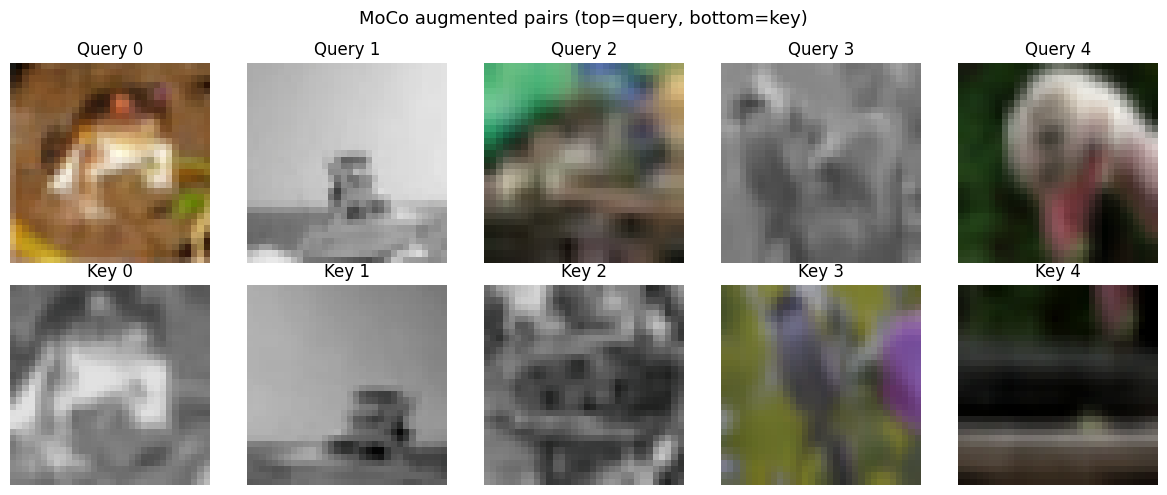

In [5]:
# ── 验证数据形状 & 可视化增强对 ──
sample_q, sample_k = pretrain_dataset[0]
print(f'Query view shape: {sample_q.shape}')   # (3, 32, 32)
print(f'Key view shape:   {sample_k.shape}')   # (3, 32, 32)

# 可视化：同一图像的两个增强视图
def denormalize(tensor, mean=(0.4914, 0.4822, 0.4465), std=(0.2470, 0.2435, 0.2616)):
    t = tensor.clone()
    for c in range(3):
        t[c] = t[c] * std[c] + mean[c]
    return t.clamp(0, 1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle('MoCo augmented pairs (top=query, bottom=key)', fontsize=13)
for i in range(5):
    q, k = pretrain_dataset[i * 100]
    axes[0, i].imshow(denormalize(q).permute(1, 2, 0).numpy())
    axes[0, i].set_title(f'Query {i}')
    axes[0, i].axis('off')
    axes[1, i].imshow(denormalize(k).permute(1, 2, 0).numpy())
    axes[1, i].set_title(f'Key {i}')
    axes[1, i].axis('off')
plt.tight_layout()
plt.show()

## 2. 共享组件

超参数集中管理，两种实现共用同一套配置，确保公平比较。

In [6]:
# ── 超参数（两种实现共用，集中管理） ──
FEATURE_DIM  = 128    # 编码器输出特征维度（论文 128）
QUEUE_SIZE   = 4096   # 动态队列大小（论文 65536，此处缩小以适配 CPU）
MOMENTUM     = 0.999  # 动量系数 m（论文 0.999）
TEMPERATURE  = 0.07   # 温度参数 τ（论文 0.07）
LR           = 1e-3   # 学习率
NUM_EPOCHS   = 20     # 预训练轮数（CPU 友好）
BATCH_SIZE   = 128    # Mini-batch 大小
EVAL_EPOCHS  = 30     # 线性评估训练轮数

pretrain_loader = DataLoader(pretrain_dataset, batch_size=BATCH_SIZE,
                             shuffle=True, drop_last=True, num_workers=0)
eval_loader = DataLoader(eval_dataset, batch_size=BATCH_SIZE,
                         shuffle=True, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                         shuffle=False, num_workers=0)

In [7]:
# ── 共享工具函数 ──
def train_moco(model, loader, optimizer, num_epochs, device):
    """MoCo 预训练循环."""
    model.train()
    model.to(device)
    losses = []
    for epoch in range(num_epochs):
        epoch_loss = 0.0
        for x_q, x_k in loader:
            x_q, x_k = x_q.to(device), x_k.to(device)  # (B, 3, 32, 32)
            loss = model(x_q, x_k)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            # 动量更新 key 编码器
            model.momentum_update()
            epoch_loss += loss.item()
        avg_loss = epoch_loss / len(loader)
        losses.append(avg_loss)
        if (epoch + 1) % 5 == 0:
            print(f'  Epoch [{epoch+1}/{num_epochs}]  Loss: {avg_loss:.4f}')
    return losses


def linear_eval(encoder, train_loader, test_loader, feature_dim,
                num_classes, num_epochs, device):
    """冻结编码器，训练线性分类头评估特征质量."""
    encoder.eval()
    encoder.to(device)
    classifier = nn.Linear(feature_dim, num_classes).to(device)
    optimizer = torch.optim.Adam(classifier.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()

    # 提取特征（一次性）
    def extract(loader):
        feats, labels = [], []
        with torch.no_grad():
            for x, y in loader:
                f = encoder(x.to(device))  # (B, feature_dim)
                feats.append(f.cpu())
                labels.append(y)
        return torch.cat(feats), torch.cat(labels)

    train_feats, train_labels = extract(train_loader)
    test_feats, test_labels = extract(test_loader)
    train_ds = torch.utils.data.TensorDataset(train_feats, train_labels)
    test_ds = torch.utils.data.TensorDataset(test_feats, test_labels)
    tr_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
    te_loader = DataLoader(test_ds, batch_size=256)

    # 训练线性头
    for epoch in range(num_epochs):
        classifier.train()
        for feats, labels in tr_loader:
            feats, labels = feats.to(device), labels.to(device)
            out = classifier(feats)
            loss = criterion(out, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # 测试
    classifier.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for feats, labels in te_loader:
            feats, labels = feats.to(device), labels.to(device)
            preds = classifier(feats).argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    acc = correct / total
    print(f'  Linear evaluation accuracy: {acc:.4f} ({correct}/{total})')
    return acc

## 2.5 MoCo 训练伪代码解读 (Algorithm 1)

论文中给出了 PyTorch 风格的训练伪代码，下面逐步解读每一行的作用。

### 完整训练流程

```python
# f_q, f_k: query/key 编码器网络
# queue:    负样本队列 (d × K)
# m:        动量系数
# t:        温度参数

for x in loader:                   # 加载 mini-batch 图像
    x_q = aug(x)                   # 对 x 做随机增强，得到 query 视图
    x_k = aug(x)                   # 对 x 做另一次随机增强，得到 key 视图

    q = f_q(x_q)                   # query 编码: (N, d)，需要梯度
    k = f_k(x_k)                   # key 编码:   (N, d)，不需要梯度
    k = k.detach()                 # ★ 关键：截断 key 的梯度

    # 正样本 logits: N×1
    l_pos = bmm(q.view(N,1,d), k.view(N,d,1))  # (N, 1)
    # 负样本 logits: N×K
    l_neg = mm(q, queue)                         # (N, d) × (d, K) → (N, K)

    logits = cat([l_pos, l_neg], dim=1) / t      # (N, 1+K)
    labels = zeros(N)                             # ★ 正样本始终在第 0 列

    loss = CrossEntropyLoss(logits, labels)

    loss.backward()                # 仅更新 f_q 的参数
    update(f_q.params)             # SGD/Adam 更新 query 编码器

    # 动量更新 key 编码器
    f_k.params = m * f_k.params + (1 - m) * f_q.params

    # 入队当前 batch 的 key，出队最旧的
    enqueue(queue, k)
    dequeue(queue)
```

### 三个关键设计点

**1. `labels = zeros(N)`**

正样本（$k^+$）始终被拼接在 logits 的第 0 列，因此 Cross Entropy 的 ground-truth 标签全为 0。这是将对比学习转化为 $(K+1)$ 类 softmax 分类的巧妙手法。

**2. `k = k.detach()`**

`detach()` 生成一个与原 tensor 共享数据但**脱离计算图**的新 tensor。这确保 `loss.backward()` 时梯度**不会回传到 key 编码器** $f_k$。key 编码器仅通过动量公式更新。

如果不 detach：
- 梯度会同时更新 $f_q$ 和 $f_k$ → key 编码器参数剧烈变化 → 队列中旧 key 失效 → 训练崩溃

**3. 先 backward 再动量更新**

训练循环的顺序是严格的：
1. 前向传播 → 计算 loss
2. `loss.backward()` → 计算 $f_q$ 的梯度
3. `update(f_q.params)` → 更新 $f_q$
4. 动量更新 $f_k$ → 缓慢追踪 $f_q$
5. 入队新 key → 维护队列

> **实现说明**：在本 Notebook 的代码中，入队操作放在 `forward()` 方法内（loss 计算之后、`backward()` 调用之前）。这不影响正确性，因为 key 特征已经计算完毕并被 `detach()`，入队顺序不影响梯度计算。论文伪代码将入队放在最后是为了展示逻辑上的清晰性。

In [8]:
# ── 伪代码关键操作演示 ──
# 演示 detach() 的梯度截断效果

# 模拟 query 编码器输出（有梯度）
q_demo = torch.randn(4, 128, requires_grad=True)
# 模拟 key 编码器输出
k_demo = torch.randn(4, 128, requires_grad=True)

# 不 detach：梯度会回传到 k_demo
sim_no_detach = (q_demo * k_demo).sum()
sim_no_detach.backward()
print(f'不 detach — k_demo.grad is None? {k_demo.grad is None}')  # False，有梯度

# 重置
q_demo2 = torch.randn(4, 128, requires_grad=True)
k_demo2 = torch.randn(4, 128, requires_grad=True)

# detach：梯度被截断
k_detached = k_demo2.detach()  # ★ 脱离计算图
sim_detach = (q_demo2 * k_detached).sum()
sim_detach.backward()
print(f'detach 后 — k_demo2.grad is None? {k_demo2.grad is None}')  # True，无梯度
print(f'detach 后 — q_demo2.grad is None? {q_demo2.grad is None}')  # False，q 仍有梯度

# 演示 labels = zeros(N) 的含义
N = 4
logits_demo = torch.randn(N, 1 + 4096)  # (N, 1+K)
labels_demo = torch.zeros(N, dtype=torch.long)  # 正样本在 index 0
loss_demo = F.cross_entropy(logits_demo, labels_demo)
print(f'\nlabels = zeros({N}): {labels_demo.tolist()}')
print(f'含义: 正样本始终在 logits 的第 0 列，CE 目标是最大化第 0 列的 softmax 概率')

不 detach — k_demo.grad is None? False
detach 后 — k_demo2.grad is None? True
detach 后 — q_demo2.grad is None? False

labels = zeros(4): [0, 0, 0, 0]
含义: 正样本始终在 logits 的第 0 列，CE 目标是最大化第 0 列的 softmax 概率


## 3. 实现 A — 源代码实现

逐组件手写 MoCo 的全部核心模块，按数据流顺序依次实现：

1. **编码器 (Encoder)** — 提取图像特征
2. **InfoNCE 损失** — 对比学习目标函数
3. **动态队列 (Queue)** — 维护大规模负样本字典
4. **动量更新 (Momentum Update)** — 保持 key 编码器一致性
5. **完整 MoCo 模型** — 组装所有组件

### 3.1 编码器架构

MoCo 原论文使用 ResNet-50 作为编码器。这里为适配 CPU 训练，使用一个轻量 CNN：
4 层卷积 + 全局平均池化 + 线性投影头，输出 $d = 128$ 维的归一化特征向量。

query 编码器和 key 编码器 **架构相同**，但参数更新方式不同：
- $\theta_q$：通过反向传播梯度下降更新
- $\theta_k$：通过动量公式 $\theta_k \leftarrow m \cdot \theta_k + (1-m) \cdot \theta_q$ 更新

In [9]:
class Encoder(nn.Module):
    """轻量 CNN 编码器 + 投影头.

    数据流: (B, 3, 32, 32) → Conv layers → GAP → projection → L2 norm → (B, feature_dim)
    """
    def __init__(self, feature_dim=128):
        super().__init__()
        # 卷积骨干：逐步扩大通道，缩小空间分辨率
        self.backbone = nn.Sequential(
            # (B, 3, 32, 32) → (B, 32, 16, 16)
            nn.Conv2d(3, 32, 3, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            # (B, 32, 16, 16) → (B, 64, 8, 8)
            nn.Conv2d(32, 64, 3, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            # (B, 64, 8, 8) → (B, 128, 4, 4)
            nn.Conv2d(64, 128, 3, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            # (B, 128, 4, 4) → (B, 256, 2, 2)
            nn.Conv2d(128, 256, 3, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            # 全局平均池化 → (B, 256, 1, 1)
            nn.AdaptiveAvgPool2d(1),
        )
        # 投影头 (projection head): 256 → feature_dim
        self.projection = nn.Sequential(
            nn.Linear(256, 256),
            nn.ReLU(inplace=True),
            nn.Linear(256, feature_dim),
        )

    def forward(self, x):
        # x: (B, 3, 32, 32)
        h = self.backbone(x)      # (B, 256, 1, 1)
        h = h.view(h.size(0), -1) # (B, 256)
        z = self.projection(h)    # (B, feature_dim)
        return F.normalize(z, dim=1)  # L2 归一化 → 单位超球面

# 验证编码器输出
_test_enc = Encoder(FEATURE_DIM)
_test_out = _test_enc(torch.randn(4, 3, 32, 32))
print(f'Encoder output shape: {_test_out.shape}')  # (4, 128)
print(f'L2 norm ≈ 1.0: {_test_out.norm(dim=1)}')

Encoder output shape: torch.Size([4, 128])
L2 norm ≈ 1.0: tensor([1.0000, 1.0000, 1.0000, 1.0000], grad_fn=<LinalgVectorNormBackward0>)


### 3.2 InfoNCE 损失函数

InfoNCE 是 MoCo 的目标函数，本质是一个 $(K+1)$ 路的 softmax 分类问题——将 query 与 1 个正样本 $k^+$ 和 $K$ 个负样本 $k^-$ 的相似度做对比：

$$\mathcal{L}_{\text{InfoNCE}} = -\log \frac{\exp(q \cdot k^+ / \tau)}{\exp(q \cdot k^+ / \tau) + \sum_{i=1}^{K} \exp(q \cdot k_i^- / \tau)}$$

**推导直觉**：
- 分子 $\exp(q \cdot k^+ / \tau)$：query 与正样本的相似度越高，分子越大
- 分母：对所有样本（正 + 负）做 softmax 归一化
- 温度 $\tau$：控制分布的"尖锐度"，$\tau$ 越小分布越集中在最高相似度项
- 等价于让 label=0 的 Cross Entropy（正样本在第 0 位）

输入/输出张量形状：
- $q$: `(B, d)` — query 特征
- $k^+$: `(B, d)` — 正样本特征
- queue: `(d, K)` — 队列中的负样本
- logits: `(B, 1+K)` — 拼接后的相似度
- loss: 标量

In [10]:
def info_nce_loss(q, k_pos, queue, temperature):
    """计算 InfoNCE 损失.

    Args:
        q:     (B, d) — query 特征（已 L2 归一化）
        k_pos: (B, d) — 正样本特征（已 L2 归一化）
        queue: (d, K) — 队列中的负样本特征
        temperature: float — 温度参数 τ
    Returns:
        loss: 标量
    """
    # 正样本相似度: q · k+ → (B, 1)
    l_pos = torch.einsum('bd,bd->b', q, k_pos).unsqueeze(1)  # (B, 1)

    # 负样本相似度: q · queue → (B, K)
    l_neg = torch.mm(q, queue)  # (B, d) × (d, K) → (B, K)

    # 拼接 logits: 正样本在第 0 位 → (B, 1+K)
    logits = torch.cat([l_pos, l_neg], dim=1) / temperature

    # 标签：正样本始终在 index=0
    labels = torch.zeros(logits.size(0), dtype=torch.long, device=q.device)

    return F.cross_entropy(logits, labels)

# 验证
_q = F.normalize(torch.randn(4, 128), dim=1)
_k = F.normalize(torch.randn(4, 128), dim=1)
_queue = F.normalize(torch.randn(128, 4096), dim=0)
print(f'InfoNCE loss: {info_nce_loss(_q, _k, _queue, 0.07):.4f}')

InfoNCE loss: 9.5779


### 3.3 动态队列 (Dynamic Queue)

队列是 MoCo 解耦字典大小与 batch 大小的核心设计：

- **结构**：FIFO 先进先出队列，大小固定为 $K$
- **入队**：每个 mini-batch 的 key 特征编码后入队
- **出队**：最早入队的 key 被移除
- **用途**：队列中所有 key 作为当前 batch 的负样本

实现细节：使用 `register_buffer` 存储队列张量，避免被优化器更新，同时自动随模型移动到正确设备。队列指针 `ptr` 跟踪下一个写入位置。

$$\text{queue}[:,\text{ptr}:\text{ptr}+B] \leftarrow k^T \quad\text{(入队当前 batch 的 keys)}$$

### 3.4 动量更新 (Momentum Update)

动量编码器的参数不通过反向传播更新，而是缓慢"追踪"查询编码器：

$$\theta_k \leftarrow m \cdot \theta_k + (1 - m) \cdot \theta_q$$

- $m = 0.999$：key 编码器每步仅更新 0.1% 来自 query 编码器
- 确保队列中不同时间步的 key 是由"几乎相同"的编码器生成的
- 极大的 $m$ 保证了表示的一致性（consistency）

### 3.5 完整 MoCo 模型

将编码器、队列、动量更新、InfoNCE 损失组装为完整的 MoCo 框架。

**前向传播数据流**：

```
x_q ──→ query_encoder ──→ q (B, d)  ──┐
                                       ├──→ InfoNCE Loss
x_k ──→ key_encoder   ──→ k (B, d)  ──┤
              ↑ (no grad)              │
              │ momentum update        │
              │                  queue (d, K) ──→ 负样本
              │                        │
              └────────────────────────┘
                   入队 k → 更新 queue
```

### 训练 vs 推理（下游评估）的区别

| 阶段 | 行为 | 关键操作 |
|------|------|---------|
| **预训练** | 对比学习，无标签 | query/key 编码 → InfoNCE → 动量更新 → 队列维护 |
| **下游评估** | 冻结编码器，训练线性头 | 仅用 query 编码器提取特征 → 线性分类器 |

预训练完成后，**只保留 query 编码器**作为特征提取器，丢弃 key 编码器和队列。

In [11]:
class MoCoV1(nn.Module):
    """MoCo v1 完整实现：query 编码器 + 动量 key 编码器 + 动态队列."""

    def __init__(self, feature_dim=128, queue_size=4096, momentum=0.999,
                 temperature=0.07):
        super().__init__()
        self.m = momentum
        self.T = temperature
        self.K = queue_size

        # query 编码器：正常梯度更新
        self.encoder_q = Encoder(feature_dim)
        # key 编码器：动量更新（初始化为 query 编码器的拷贝）
        self.encoder_k = copy.deepcopy(self.encoder_q)
        # key 编码器不参与反向传播
        for p in self.encoder_k.parameters():
            p.requires_grad = False

        # ── 动态队列 ──
        # 使用 register_buffer 使队列不被优化器更新，但自动随模型 .to(device)
        self.register_buffer('queue', F.normalize(torch.randn(feature_dim, queue_size), dim=0))
        self.register_buffer('queue_ptr', torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _enqueue(self, keys):
        """将当前 batch 的 key 特征入队，同时出队最旧的.

        keys: (B, d) — 当前 batch 经 key 编码器得到的特征
        """
        batch_size = keys.size(0)
        ptr = int(self.queue_ptr)

        # 如果 batch 超出队列尾部，分两段写入（环形队列）
        if ptr + batch_size > self.K:
            remaining = self.K - ptr
            self.queue[:, ptr:] = keys[:remaining].T
            self.queue[:, :batch_size - remaining] = keys[remaining:].T
        else:
            self.queue[:, ptr:ptr + batch_size] = keys.T  # (d, B) 写入

        # 移动指针（取模实现环形）
        self.queue_ptr[0] = (ptr + batch_size) % self.K

    @torch.no_grad()
    def momentum_update(self):
        """动量更新 key 编码器: θ_k ← m·θ_k + (1-m)·θ_q."""
        for p_q, p_k in zip(self.encoder_q.parameters(),
                            self.encoder_k.parameters()):
            p_k.data = self.m * p_k.data + (1.0 - self.m) * p_q.data

    def forward(self, x_q, x_k):
        """前向传播，返回 InfoNCE 损失.

        x_q: (B, 3, 32, 32) — query 视图
        x_k: (B, 3, 32, 32) — key 视图
        """
        # query 编码（需要梯度）
        q = self.encoder_q(x_q)  # (B, d)

        # key 编码（不需要梯度，key 编码器不参与反向传播）
        with torch.no_grad():
            k = self.encoder_k(x_k)  # (B, d)

        # 计算 InfoNCE 损失
        loss = info_nce_loss(q, k, self.queue.clone().detach(), self.T)

        # 入队当前 batch 的 key
        self._enqueue(k)

        return loss

    def get_encoder(self):
        """返回预训练完成的 query 编码器（用于下游评估）."""
        return self.encoder_q


# 验证模型
_model = MoCoV1(FEATURE_DIM, QUEUE_SIZE, MOMENTUM, TEMPERATURE)
_loss = _model(torch.randn(4, 3, 32, 32), torch.randn(4, 3, 32, 32))
print(f'MoCoV1 output loss: {_loss.item():.4f}')
print(f'Queue shape: {_model.queue.shape}')  # (128, 4096)
print(f'Total params: {sum(p.numel() for p in _model.parameters()):,}')

MoCoV1 output loss: 0.1043
Queue shape: torch.Size([128, 4096])
Total params: 976,128


### 3.6 预训练

使用 InfoNCE 损失在无标签数据上预训练 MoCo 模型。

=== 实现 A: 源代码实现 — 预训练 ===
  Epoch [5/20]  Loss: 6.8696
  Epoch [10/20]  Loss: 6.4537
  Epoch [15/20]  Loss: 6.1233
  Epoch [20/20]  Loss: 5.9626


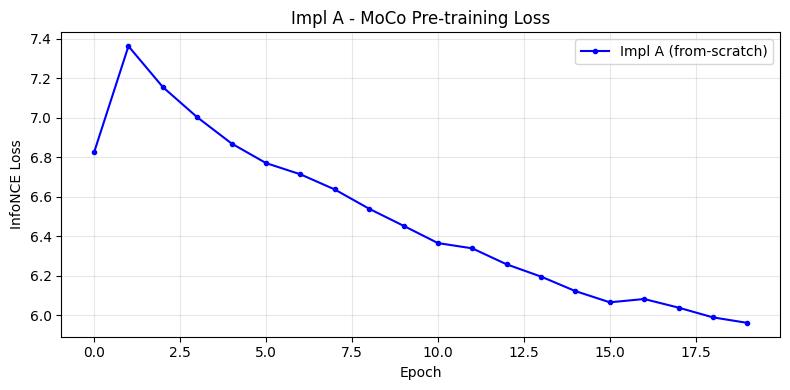

In [12]:
# ── 实现 A 预训练 ──
print('=== 实现 A: 源代码实现 — 预训练 ===')
model_a = MoCoV1(FEATURE_DIM, QUEUE_SIZE, MOMENTUM, TEMPERATURE)
optimizer_a = torch.optim.Adam(model_a.encoder_q.parameters(), lr=LR)
losses_a = train_moco(model_a, pretrain_loader, optimizer_a, NUM_EPOCHS, device)

plt.figure(figsize=(8, 4))
plt.plot(losses_a, 'b-o', markersize=3, label='Impl A (from-scratch)')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('Impl A - MoCo Pre-training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.7 线性评估（下游任务）

**线性评估协议** (Linear Evaluation Protocol) 是衡量自监督预训练特征质量的标准方法：

1. **冻结**预训练好的编码器（不更新其参数）
2. 在编码器输出之上训练一个**线性分类头**（单层全连接）
3. 在测试集上评估分类准确率

如果编码器学到了好的语义特征，即使只用线性分类器也应该能达到不错的分类效果。

In [13]:
# ── 实现 A 线性评估 ──
print('=== 实现 A: 线性评估 ===')
encoder_a = model_a.get_encoder()
acc_a = linear_eval(encoder_a, eval_loader, test_loader,
                    FEATURE_DIM, num_classes=10, num_epochs=EVAL_EPOCHS,
                    device=device)

=== 实现 A: 线性评估 ===
  Linear evaluation accuracy: 0.4230 (423/1000)


## 4. 实现 B — 简洁实现

使用 `torchvision.models.resnet18` 作为编码器 backbone，简化 MoCo 封装。

| 源代码实现 | 简洁实现 |
|---|---|
| `Encoder` (手写 4 层 CNN + 投影头) | `torchvision.models.resnet18` (修改 conv1 + fc) |
| `info_nce_loss` (独立函数) | 内嵌于 `forward` 方法 |
| `MoCoV1` (手写队列管理 + 动量更新) | `MoCoCompact` (相同逻辑，更紧凑封装) |

In [14]:
def _make_resnet_encoder(feature_dim):
    """构建适配 CIFAR-10 (32×32) 的 ResNet-18 编码器."""
    net = torchvision.models.resnet18(weights=None)
    # 原始 ResNet-18 的 conv1 是 7×7 stride=2，适合 224×224 输入
    # 对于 32×32 的 CIFAR，改为 3×3 stride=1，避免过度下采样
    net.conv1 = nn.Conv2d(3, 64, 3, stride=1, padding=1, bias=False)
    net.maxpool = nn.Identity()  # 移除 maxpool，保留空间分辨率
    # 替换分类头为投影头
    in_features = net.fc.in_features  # 512
    net.fc = nn.Sequential(
        nn.Linear(in_features, in_features),
        nn.ReLU(inplace=True),
        nn.Linear(in_features, feature_dim),
    )
    return net


class ResNetEncoder(nn.Module):
    """ResNet-18 编码器包装，输出 L2 归一化特征."""
    def __init__(self, feature_dim=128):
        super().__init__()
        self.net = _make_resnet_encoder(feature_dim)

    def forward(self, x):
        return F.normalize(self.net(x), dim=1)  # (B, feature_dim)


class MoCoCompact(nn.Module):
    """MoCo 简洁实现：使用 ResNet-18 backbone."""

    def __init__(self, feature_dim=128, queue_size=4096, momentum=0.999,
                 temperature=0.07):
        super().__init__()
        self.m, self.T, self.K = momentum, temperature, queue_size
        self.encoder_q = ResNetEncoder(feature_dim)
        self.encoder_k = copy.deepcopy(self.encoder_q)
        for p in self.encoder_k.parameters():
            p.requires_grad = False
        self.register_buffer('queue',
                             F.normalize(torch.randn(feature_dim, queue_size), dim=0))
        self.register_buffer('queue_ptr', torch.zeros(1, dtype=torch.long))

    @torch.no_grad()
    def _enqueue(self, keys):
        B = keys.size(0)
        ptr = int(self.queue_ptr)
        if ptr + B > self.K:
            r = self.K - ptr
            self.queue[:, ptr:] = keys[:r].T
            self.queue[:, :B - r] = keys[r:].T
        else:
            self.queue[:, ptr:ptr + B] = keys.T
        self.queue_ptr[0] = (ptr + B) % self.K

    @torch.no_grad()
    def momentum_update(self):
        for p_q, p_k in zip(self.encoder_q.parameters(),
                            self.encoder_k.parameters()):
            p_k.data.mul_(self.m).add_((1.0 - self.m) * p_q.data)

    def forward(self, x_q, x_k):
        q = self.encoder_q(x_q)               # (B, d)
        with torch.no_grad():
            k = self.encoder_k(x_k)            # (B, d)
        # InfoNCE（内联计算）
        l_pos = (q * k).sum(dim=1, keepdim=True)           # (B, 1)
        l_neg = q @ self.queue.clone().detach()             # (B, K)
        logits = torch.cat([l_pos, l_neg], dim=1) / self.T # (B, 1+K)
        labels = torch.zeros(q.size(0), dtype=torch.long, device=q.device)
        loss = F.cross_entropy(logits, labels)
        self._enqueue(k)
        return loss

    def get_encoder(self):
        return self.encoder_q

# 验证
_model_b = MoCoCompact(FEATURE_DIM, QUEUE_SIZE, MOMENTUM, TEMPERATURE)
_loss_b = _model_b(torch.randn(4, 3, 32, 32), torch.randn(4, 3, 32, 32))
print(f'MoCoCompact output loss: {_loss_b.item():.4f}')
print(f'Total params: {sum(p.numel() for p in _model_b.parameters()):,}')

MoCoCompact output loss: 0.0111
Total params: 22,994,304


=== 实现 B: 简洁实现 — 预训练 ===
  Epoch [5/20]  Loss: 6.7559
  Epoch [10/20]  Loss: 6.7221
  Epoch [15/20]  Loss: 6.6670
  Epoch [20/20]  Loss: 6.4719


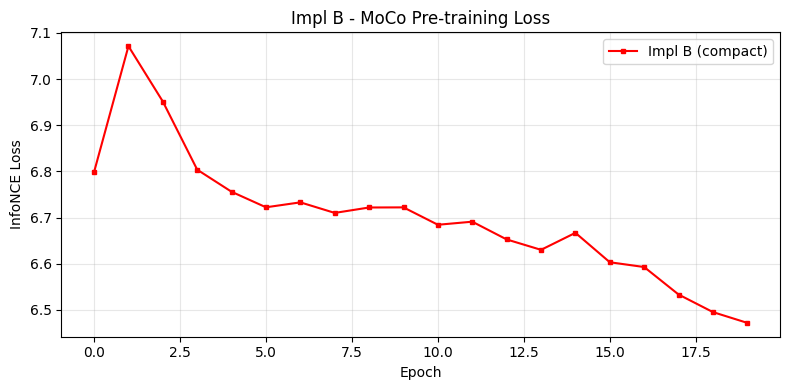

In [15]:
# ── 实现 B 预训练 ──
print('=== 实现 B: 简洁实现 — 预训练 ===')
model_b = MoCoCompact(FEATURE_DIM, QUEUE_SIZE, MOMENTUM, TEMPERATURE)
optimizer_b = torch.optim.Adam(model_b.encoder_q.parameters(), lr=LR)
losses_b = train_moco(model_b, pretrain_loader, optimizer_b, NUM_EPOCHS, device)

plt.figure(figsize=(8, 4))
plt.plot(losses_b, 'r-s', markersize=3, label='Impl B (compact)')
plt.xlabel('Epoch')
plt.ylabel('InfoNCE Loss')
plt.title('Impl B - MoCo Pre-training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [16]:
# ── 实现 B 线性评估 ──
print('=== 实现 B: 线性评估 ===')
encoder_b = model_b.get_encoder()
acc_b = linear_eval(encoder_b, eval_loader, test_loader,
                    FEATURE_DIM, num_classes=10, num_epochs=EVAL_EPOCHS,
                    device=device)

=== 实现 B: 线性评估 ===
  Linear evaluation accuracy: 0.3290 (329/1000)


## 5. 结果对比

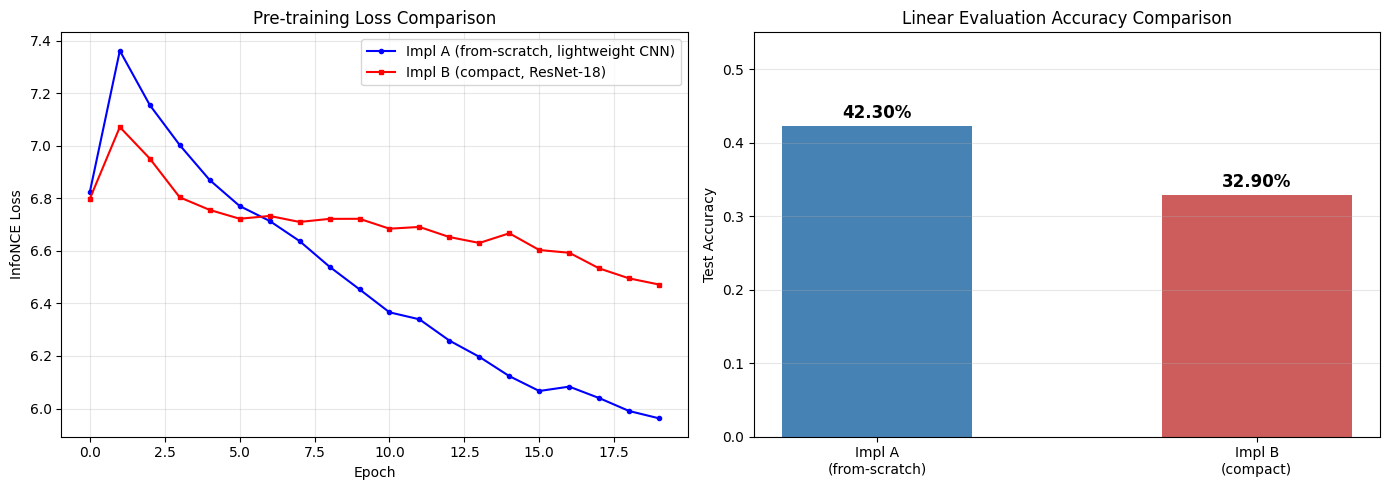


实现 A (源代码, 轻量 CNN) 线性评估准确率: 0.4230
实现 B (简洁, ResNet-18)  线性评估准确率: 0.3290


In [17]:
# ── 损失曲线对比 ──
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：预训练损失
axes[0].plot(losses_a, 'b-o', markersize=3, label='Impl A (from-scratch, lightweight CNN)')
axes[0].plot(losses_b, 'r-s', markersize=3, label='Impl B (compact, ResNet-18)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('InfoNCE Loss')
axes[0].set_title('Pre-training Loss Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 右图：线性评估准确率
bars = axes[1].bar(['Impl A\n(from-scratch)', 'Impl B\n(compact)'],
                   [acc_a, acc_b],
                   color=['steelblue', 'indianred'], width=0.5)
axes[1].set_ylabel('Test Accuracy')
axes[1].set_title('Linear Evaluation Accuracy Comparison')
axes[1].set_ylim(0, max(acc_a, acc_b) * 1.3)
for bar, acc in zip(bars, [acc_a, acc_b]):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
                 f'{acc:.2%}', ha='center', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f'\n{"="*50}')
print(f'实现 A (源代码, 轻量 CNN) 线性评估准确率: {acc_a:.4f}')
print(f'实现 B (简洁, ResNet-18)  线性评估准确率: {acc_b:.4f}')
print(f'{"="*50}')

## 附录 B：面试拓展

### 高频面试题

**Q1: MoCo 为什么需要动量编码器？直接用同一个编码器（参数共享）行不行？**

- 如果 query 和 key 共享同一个编码器，则队列中的所有 key 必须在每个 step 重新计算（因为编码器参数变了），这等同于端到端方法，字典大小受限于 batch size
- 动量编码器的核心作用是保持 **表示一致性**：由于 $m=0.999$，key 编码器参数每步只变化 0.1%，确保队列中不同时间步生成的 key 使用"几乎相同"的编码标准
- 实验表明：$m$ 太小（如 0.9）会导致训练不稳定；$m$ 太大（如 0.9999）收敛太慢

**Q2: MoCo 的队列大小 K 如何影响训练效果？**

- **K 越大**：更多负样本 → InfoNCE 的分母覆盖更广 → 学到的特征更具判别力
- **K 越小**：负样本不足 → 模型容易找到"捷径"区分正负样本 → 特征质量下降
- 论文实验：K=65536 表现最好，K 从 1024 到 65536 单调提升
- 关键优势：队列大小与 batch size 解耦，不受 GPU 内存限制

**Q3: InfoNCE 和 Cross Entropy 有什么关系？**

- InfoNCE 本质上**就是** Cross Entropy：将正样本视为 label=0 的类别，$K$ 个负样本视为其他类别
- 区别在于"类别"的定义：CE 中类别是语义标签（猫/狗），InfoNCE 中每个样本就是一个"类别"
- 温度 $\tau$ 控制分布的尖锐度：$\tau \to 0$ 时退化为 hard argmax，$\tau \to \infty$ 时变成均匀分布

**Q4: MoCo 和 SimCLR 的核心区别是什么？**

- **字典大小**：SimCLR 的负样本来自同一 batch（字典大小=2×batch_size-2），MoCo 使用队列（字典大小可远大于 batch size）
- **编码器更新**：SimCLR 两个编码器都通过反向传播更新（端到端），MoCo 的 key 编码器通过动量更新
- **硬件需求**：SimCLR 需要大 batch size（4096+8 GPU TPU），MoCo 可在普通硬件上训练
- **一致性**：SimCLR 天然一致（同一 batch 同一编码器），MoCo 通过动量保证近似一致性

**Q5: 为什么 MoCo 的 key 编码器不能直接反向传播？**

- 如果 key 编码器也反向传播，则每次参数更新后队列中所有旧的 key 就"过时"了（用旧参数编码的特征与新参数不匹配）
- 动量更新保证 key 编码器的变化是缓慢的、渐进的，旧 key 和新 key 之间的差异很小
- 这是 MoCo 能使用大队列的根本原因

**Q6: MoCo v2 相比 v1 做了哪些改进？**

- 引入 SimCLR 的 **MLP 投影头**（两层 MLP 代替单层线性投影）
- 使用更强的 **数据增强**（加入 blur）
- 使用 **余弦学习率衰减**
- 这些改进都来自 SimCLR 的实验发现，说明 MoCo 框架具有很好的兼容性

**Q7: 对比学习中温度参数 τ 的作用是什么？如何选择？**

- $\tau$ 小 → softmax 输出更"尖锐" → 模型更关注最困难的负样本 → 学习更精细的特征，但训练可能不稳定
- $\tau$ 大 → softmax 输出更平滑 → 模型平等对待所有负样本 → 学习更鲁棒但可能不够精细
- 典型值：MoCo 用 0.07，SimCLR 用 0.5（因为 SimCLR 负样本更少，需要更平滑的梯度）

**Q8: MoCo 的预训练-微调范式和端到端监督学习有什么优劣？**

- **优势**：不需要标注数据；可利用海量无标签数据；预训练特征通用性强，可迁移到多个下游任务
- **劣势**：需要额外的预训练阶段；在数据量相当时通常不如监督学习；超参数敏感（$\tau$, $m$, $K$, 数据增强策略）
- 当标注数据稀缺时，自监督预训练 + 少量标注微调效果显著优于纯监督学习

**Q9: `k.detach()` 在 MoCo 训练中起什么作用？不写会怎样？**

- `detach()` 将 tensor 从计算图中分离，生成共享数据但无梯度追踪的新 tensor
- **作用**：确保 `loss.backward()` 时梯度只回传到 query 编码器 $f_q$，不会影响 key 编码器 $f_k$
- **不写的后果**：梯度会同时流过 $f_q$ 和 $f_k$，导致 key 编码器参数每步剧烈变化，破坏队列中 key 的一致性，训练可能直接崩溃
- 注意：在实现中等效地可以用 `with torch.no_grad():` 包裹 key 编码的前向传播，效果相同

**Q10: MoCo 的 InfoNCE 损失与噪声对比估计 (NCE) 有什么联系？**

- InfoNCE 是 NCE 的一种特殊形式。NCE 的目标是区分"真实样本"（正样本分布）和"噪声样本"（噪声分布）
- 在 MoCo 中，正样本对应同一图像的不同增强视图，噪声分布对应队列中的其他样本
- NCE 将密度比估计转化为二分类问题，而 InfoNCE 推广为 $(K+1)$ 类分类
- 理论上，InfoNCE 损失的下界与正样本对之间的互信息 (mutual information) 相关：$\mathcal{L}_{\text{InfoNCE}} \geq \log(K+1) - I(q; k^+)$

### 创新点总结

| 创新点 | 解决的问题 | 机制 |
|--------|-----------|------|
| 动态队列 | 字典大小受限于 batch size | FIFO 队列解耦字典大小与 batch size |
| 动量编码器 | 大字典中表示不一致 | $\theta_k \leftarrow m \cdot \theta_k + (1-m) \cdot \theta_q$ 缓慢更新 |
| 简洁设计 | 其他方法需大 batch / 多 GPU | 不需要大 batch 训练，单 GPU 可运行 |

### 延伸阅读与对比

| 对比维度 | MoCo | SimCLR | BYOL | SwAV |
|---------|------|--------|------|------|
| 核心思想 | 动量编码器 + 动态队列 | 端到端大 batch 对比 | 无需负样本，自蒸馏 | 在线聚类 + 对比 |
| 负样本来源 | 动态队列 (K=65536) | 同一 batch (2N-2) | 不需要负样本 | 聚类原型 |
| 硬件需求 | 低（单 GPU 可训练） | 高（需大 batch） | 中等 | 中等 |
| 关键创新 | 动量更新解决一致性 | 证明数据增强和投影头的重要性 | 证明负样本非必需 | 在线聚类避免模式坍塌 |
| ImageNet Top-1 | 60.6% (v1) / 71.1% (v2) | 69.3% (batch=4096) | 74.3% | 75.3% |

### 理论基础

MoCo 通过对比学习隐式地学习了数据分布的特征，使得相似实例在特征空间中靠近、不相似实例远离，与**信息最大化理论**相符：
- 编码器学到的表示最大化了输入与表示之间的互信息
- InfoNCE 损失提供了互信息的下界估计
- 这一理论框架解释了为什么对比学习预训练的特征能够迁移到多种下游任务

### 进阶探索方向

- **MoCo v3**：将 MoCo 框架迁移到 Vision Transformer，证明动量编码器对 ViT 训练的稳定性作用
- **DINO**：结合自蒸馏和 ViT，无需负样本和队列，在 ViT 上实现了强大的自监督特征
- **MAE**：从对比学习转向掩码图像建模，通过重建被遮蔽的 patch 学习特征，计算效率更高
- **多模态对比学习（CLIP）**：将视觉-语言对比学习推广到更大规模，实现零样本迁移